# Safest Aircraft Data Analysis

## Introduction

The company is expanding into new industries to diversify its portfolio. They are interested in purchasing and operating airplanes for commercial and private enterprises. 

As the company is not aware of the potential risks of aircrafts, this analysis aims to determine which aircraft are the lowest risk for the company to start this new business endeavour. 

The goal is to provide the head of the new aviation division some recommendations that can help them decide which aircraft(s) to purchase.

**Table of Contents**
- [Data Understanding](#understanding)
- [Data Preparation](#preparation)
    - [Remove duplicates](#duplicates)
    - [Handle missing values](#missing)
    - [Transform the data](#transform)
- [Data Analysis](#analysis)
    - [Level of Injury](#injury)
    - [Accidents vs Incidents](#accidents)
    - [Level of Aircraft Damage](#damage)
- [Conclusion and Next Steps](#conclusion)
- [References](#references)

<a id="understanding"></a>
## Data Understanding

The dataset is from the National Transportation Safety Board and it includes aviation accident data from 1962 to 2023, specifically, civil aviation accidents and selected incidents in United States and international waters.

**Load Dataset**

In [1]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# set the option to display all columns
pd.set_option('display.max_columns', None)

# set figsize for seaborn plots
sns.set_theme(rc={'figure.figsize': (15, 7)})

# default color palette for seaborn plots
default_palette = sns.color_palette()

# load aviation accidents data into a DataFrame
accidents_df = pd.read_csv('data/Aviation_Data.csv', low_memory=False)

# examine example of the data
accidents_df.head(10)

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,Aircraft.Category,Registration.Number,Make,Model,Amateur.Built,Number.of.Engines,Engine.Type,FAR.Description,Schedule,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,NC6404,Stinson,108-3,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,Fatal(4),Destroyed,NaN,N5069P,Piper,PA24-180,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,Fatal(3),Destroyed,NaN,N5142R,Cessna,172M,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,N1168J,Rockwell,112,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,Fatal(1),Destroyed,NaN,N15NY,Cessna,501,No,NaN,NaN,NaN,NaN,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980
5,20170710X52551,Accident,NYC79AA106,1979-09-17,"BOSTON, MA",United States,42.445277,-70.758333,NaN,NaN,Non-Fatal,Substantial,Airplane,CF-TLU,Mcdonnell Douglas,DC9,No,2.0,Turbo Fan,Part 129: Foreign,SCHD,NaN,Air Canada,NaN,NaN,1.0,44.0,VMC,Climb,Probable Cause,19-09-2017
6,20001218X45446,Accident,CHI81LA106,1981-08-01,"COTTON, MN",United States,NaN,NaN,NaN,NaN,Fatal(4),Destroyed,NaN,N4988E,Cessna,180,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,4.0,0.0,0.0,0.0,IMC,Unknown,Probable Cause,06-11-2001
7,20020909X01562,Accident,SEA82DA022,1982-01-01,"PULLMAN, WA",United States,NaN,NaN,NaN,BLACKBURN AG STRIP,Non-Fatal,Substantial,Airplane,N2482N,Cessna,140,No,1.0,Reciprocating,Part 91: General Aviation,NaN,Personal,NaN,0.0,0.0,0.0,2.0,VMC,Takeoff,Probable Cause,01-01-1982
8,20020909X01561,Accident,NYC82DA015,1982-01-01,"EAST HANOVER, NJ",United States,NaN,NaN,N58,HANOVER,Non-Fatal,Substantial,Airplane,N7967Q,Cessna,401B,No,2.0,Reciprocating,Part 91: General Aviation,NaN,Business,NaN,0.0,0.0,0.0,2.0,IMC,Landing,Probable Cause,01-01-1982
9,20020909X01560,Accident,MIA82DA029,1982-01-01,"JACKSONVILLE, FL",United States,NaN,NaN,JAX,JACKSONVILLE INTL,Non-Fatal,Substantial,NaN,N3906K,North American,NAVION L-17B,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,0.0,0.0,3.0,0.0,IMC,Cruise,Probable Cause,01-01-1982


**Data Overview**

The data contains 90,348 observations (rows) and 31 features (columns). 

In [2]:
accidents_df.shape

(90348, 31)

The following are the features (columns) of the dataset.

In [3]:
accidents_df.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

The following is the initial statistics of the dataset.

In [4]:
accidents_df.describe()

,Number.of.Engines,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured
count,82805.000000,77488.000000,76379.000000,76956.000000,82977.000000
mean,1.146585,0.647855,0.279881,0.357061,5.325440
std,0.446510,5.485960,1.544084,2.235625,27.913634
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,0.000000,0.000000,0.000000,2.000000
max,8.000000,349.000000,161.000000,380.000000,699.000000


<a id="preparation"></a>
## Data Preparation

In [5]:
# check for missing values
accidents_df.isna().sum()

Event.Id                   1459
Investigation.Type            0
Accident.Number            1459
Event.Date                 1459
Location                   1511
Country                    1685
Latitude                  55966
Longitude                 55975
Airport.Code              40099
Airport.Name              37558
Injury.Severity            2459
Aircraft.damage            4653
Aircraft.Category         58061
Registration.Number        2776
Make                       1522
Model                      1551
Amateur.Built              1561
Number.of.Engines          7543
Engine.Type                8536
FAR.Description           58325
Schedule                  77766
Purpose.of.flight          7651
Air.carrier               73700
Total.Fatal.Injuries      12860
Total.Serious.Injuries    13969
Total.Minor.Injuries      13392
Total.Uninjured            7371
Weather.Condition          5951
Broad.phase.of.flight     28624
Report.Status              7840
Publication.Date          16689
dtype: i

In [6]:
# renamed columns
accidents_df_cleaned = accidents_df.copy()
accidents_df_cleaned.columns = accidents_df_cleaned.columns.str.replace(".", " ")
accidents_df_cleaned.columns = accidents_df_cleaned.columns.str.title()
accidents_df_cleaned.columns

Index(['Event Id', 'Investigation Type', 'Accident Number', 'Event Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport Code',
       'Airport Name', 'Injury Severity', 'Aircraft Damage',
       'Aircraft Category', 'Registration Number', 'Make', 'Model',
       'Amateur Built', 'Number Of Engines', 'Engine Type', 'Far Description',
       'Schedule', 'Purpose Of Flight', 'Air Carrier', 'Total Fatal Injuries',
       'Total Serious Injuries', 'Total Minor Injuries', 'Total Uninjured',
       'Weather Condition', 'Broad Phase Of Flight', 'Report Status',
       'Publication Date'],
      dtype='object')

<a id="duplicates"></a>
### Remove duplicates

In [7]:
# drop duplicate rows
accidents_df_cleaned = accidents_df_cleaned.drop_duplicates()

In [8]:
print('Original data shape: ', accidents_df.shape)
print('Cleaned data shape: ', accidents_df_cleaned.shape)

Original data shape:  (90348, 31)
Cleaned data shape:  (88958, 31)


A total of 1390 rows / duplicates were removed.

<a id="missing"></a>
### Handle missing values

**Handle features with a high percentage of missing values**

I decided to drop the features with a high percentage of missing values that are not crucial to the analysis. I chose to replace missing values in `Aircraft Category` with the mode value as it is an important feature to keep for the analysis.

In [9]:
# drop columns that are not crucial to the analysis
accidents_df_cleaned = accidents_df_cleaned.drop(columns=['Latitude', 'Longitude', 'Airport Code', 
                                                          'Airport Name', 'Far Description', 'Schedule', 
                                                          'Air Carrier'], axis=1)

In [10]:
# for "Aircraft Category" replace NaN values with "Airplane" (mode)
accidents_df_cleaned['Aircraft Category'] = accidents_df_cleaned['Aircraft Category'].fillna('Airplane')

**Handle categorical features with some missing values**

I chose to drop the `Publication Date` feature as it's not crucial to the analysis. I replaced missing values for `Aircraft Damage` with its mode value (`Substantial`) as it's an important feature for the analysis. 

For the rest of the features, I kept them and filled in the missing values with an `Unknown` placeholder value which already exists for some features.

In [11]:
# drop "Publication Date" column as it's not crucial to the analysis
accidents_df_cleaned = accidents_df_cleaned.drop(columns=['Publication Date'], axis=1)

In [12]:
# for "Aircraft Damage" replace NaN values with "Substantial" (mode)
accidents_df_cleaned['Aircraft Damage'] = accidents_df_cleaned['Aircraft Damage'].fillna('Substantial')

In [13]:
# for these features, keep missing values, replace NaN with "Unknown"
accidents_df_cleaned['Location'] = accidents_df_cleaned['Location'].fillna('Unknown')
accidents_df_cleaned['Country'] = accidents_df_cleaned['Country'].fillna('Unknown')
accidents_df_cleaned['Injury Severity'] = accidents_df_cleaned['Injury Severity'].fillna('Unknown')
accidents_df_cleaned['Registration Number'] = accidents_df_cleaned['Registration Number'].fillna('Unknown')
accidents_df_cleaned['Make'] = accidents_df_cleaned['Make'].fillna('Unknown')
accidents_df_cleaned['Model'] = accidents_df_cleaned['Model'].fillna('Unknown')
accidents_df_cleaned['Amateur Built'] = accidents_df_cleaned['Amateur Built'].fillna('Unknown')
accidents_df_cleaned['Engine Type'] = accidents_df_cleaned['Engine Type'].fillna('Unknown')
accidents_df_cleaned['Purpose Of Flight'] = accidents_df_cleaned['Purpose Of Flight'].fillna('Unknown')
accidents_df_cleaned['Weather Condition'] = accidents_df_cleaned['Weather Condition'].fillna('UNK')
accidents_df_cleaned['Broad Phase Of Flight'] = accidents_df_cleaned['Broad Phase Of Flight'].fillna('Unknown')
accidents_df_cleaned['Report Status'] = accidents_df_cleaned['Report Status'].fillna('Unknown')

In [14]:
# fix up inconsistencies in data 
# for "Registration Number" merge "NONE" and "None"
accidents_df_cleaned.loc[accidents_df_cleaned['Registration Number'] == 'None', 'Registration Number'] = 'NONE'
# for "Engine Type" merge "NONE" and "None"
accidents_df_cleaned.loc[accidents_df_cleaned['Engine Type'] == 'None', 'Engine Type'] = 'NONE'
# for "Weather Condition" merge "UNK" and "Unk"
accidents_df_cleaned.loc[accidents_df_cleaned['Weather Condition'] == 'Unk', 'Weather Condition'] = 'UNK'

**Handle numerical features with some missing values**

I decided to replace missing values for the following numerical features with it's median value.

In [15]:
# for "Number Of Engines" replace NaN values with median value
number_of_engines_median = accidents_df_cleaned['Number Of Engines'].median()
accidents_df_cleaned = accidents_df_cleaned.fillna({ 'Number Of Engines': number_of_engines_median })

# for "Total Fatal Injuries" replace NaN values with median value
total_fatal_injuries_median = accidents_df_cleaned['Total Fatal Injuries'].median()
accidents_df_cleaned = accidents_df_cleaned.fillna({ 'Total Fatal Injuries': total_fatal_injuries_median })

# for "Total Serious Injuries" replace NaN values with median value
total_serious_injuries_median = accidents_df_cleaned['Total Serious Injuries'].median()
accidents_df_cleaned = accidents_df_cleaned.fillna({ 'Total Serious Injuries': total_serious_injuries_median })

# for "Total Minor Injuries" replace NaN values with median value
total_minor_injuries_median = accidents_df_cleaned['Total Minor Injuries'].median()
accidents_df_cleaned = accidents_df_cleaned.fillna({ 'Total Minor Injuries': total_minor_injuries_median })

# for "Total Uninjured" replace NaN values with median value
total_uninjured_median = accidents_df_cleaned['Total Uninjured'].median()
accidents_df_cleaned = accidents_df_cleaned.fillna({ 'Total Uninjured': total_uninjured_median })

**Drop rows where `Make` and `Model` are not known**

It is not possible to identify the aircraft if both `Make` and `Model` values are `Unknown`.

In [16]:
# drop rows where "Make" and "Model" are Unknown
make_model_unknown = (accidents_df_cleaned['Make'] == 'Unknown') & (accidents_df_cleaned['Model'] == 'Unknown')
accidents_df_cleaned = accidents_df_cleaned[~make_model_unknown]

In [17]:
# re-check for missing values
accidents_df_cleaned.isna().sum()

Event Id                  0
Investigation Type        0
Accident Number           0
Event Date                0
Location                  0
Country                   0
Injury Severity           0
Aircraft Damage           0
Aircraft Category         0
Registration Number       0
Make                      0
Model                     0
Amateur Built             0
Number Of Engines         0
Engine Type               0
Purpose Of Flight         0
Total Fatal Injuries      0
Total Serious Injuries    0
Total Minor Injuries      0
Total Uninjured           0
Weather Condition         0
Broad Phase Of Flight     0
Report Status             0
dtype: int64

In [18]:
print('Original data shape: ', accidents_df.shape)
print('Cleaned data shape: ', accidents_df_cleaned.shape)

Original data shape:  (90348, 31)
Cleaned data shape:  (88844, 23)


A total of 1504 rows/observations and 8 columns/features were dropped.

<a id="transform"></a>
### Transform the data

**Subset: commercially built aircraft only**

We only want data for aircraft that is commericially built. Amateur built aircraft are not suitable for the company to purchase and operate for commercial businesses. 

In [19]:
# filter out those aircraft that are amateur built
accidents_df_filtered = accidents_df_cleaned[accidents_df_cleaned['Amateur Built'] == 'No']

**Subset: Airplanes only**

The company is only interested in airplanes, therefore, we only want airplane data and not other types of aircraft i.e. helicopter, glider, balloon, etc.

In [20]:
# filter out aircraft that are not 'Airplane'
accidents_df_filtered = accidents_df_filtered[accidents_df_filtered['Aircraft Category'] == 'Airplane']

**Subset: modern business airplanes only**

Since the company would like to focus on purchasing and operating airplanes specifically for commercial and private businesses, we only want the data for modern business airplanes. 

Business airplanes, also known as business jets, typically utilize two jet turbofan engines.<sup>[[1]](#ref1)</sup>

In [21]:
# filter out older aircraft
accidents_df_filtered = accidents_df_filtered[(accidents_df_filtered['Number Of Engines'] == 2) & 
                                              (accidents_df_filtered['Engine Type'] == 'Turbo Fan')]

**Add new feature `Manufacturer`**

Adding a new feature to group `Make` values into a manufacturer. Ultimately, we need to know the manufacturer of the `Make`/`Model` of the aircraft in order to begin the process of purchasing any aircraft. The `Make` of the aircraft can be the manufacturer or simply a brand belonging to a particular manfacturer. 

In [22]:
# create a copy of the filtered DataFrame
accidents_df_final = accidents_df_filtered.copy()

# Fix all 'Make' values so they are title case
accidents_df_final['Make'] = accidents_df_final['Make'].str.title()

In [23]:
# mapping aircraft "Make" to a "Manufacturer"
aircraft_manufacturer_mappings = {
    "Bae": "BAE Systems", # BAe (British Aerospace) formed part of BAE Systems 
    "British Aerospace": "BAE Systems", # formed part of BAE Systems
    "Beech": "Textron Aviation", # now part of Textron Aviation
    "Beechcraft": "Textron Aviation", # now brand under Textron Aviation
    "Boeing Commercial Airplane Gro": "Boeing", # a division of Boeing
    "Boeing Company": "Boeing", # same thing
    "The Boeing Company": "Boeing", # same thing
    "Bombardier Aerospace, Inc.": "Bombardier", # division of Bombardier
    "Bombardier Canadair": "Bombardier", # acquired by Bombardier
    "Bombardier Inc": "Bombardier", # same thing
    "Bombardier, Inc.": "Bombardier", # same thing
    "Canadair": "Bombardier", # acquired by Bombardier
    "Canadair Ltd": "Bombardier", # acquired by Bombardier
    "Cessna Aircraft Company": "Textron Aviation", # acquired by Textron Aviation
    "Cessna": "Textron Aviation", # brand under Textron Aviation
    "Textron Aviation Inc": "Textron Aviation", # same thing
    "Dassault": "Dassault Aviation", # same thing
    "Dassault-Breguet": "Dassault Aviation", # former name after merger
    "Douglas": "Boeing", # went through mergers, now owned by Boeing
    "Mcdonnell Douglas": "Boeing", # merged with Boeing
    "Mcdonnell Douglas Aircraft Co": "Boeing", # merged with Boeing
    "Mcdonnell Douglas Corporation": "Boeing", # merged with Boeing
    "Eclipse": "Eclipse Aerospace", # Eclipse Aviation > Eclipse Aerospace
    "Eclipse Aviation": "Eclipse Aerospace", # assets now owned by Eclipse Aerospace
    "Eclipse Aviation Corp": "Eclipse Aerospace", # assets now owned by Eclipse Aerospace
    "Eclipse Aviation Corporation": "Eclipse Aerospace", # assets now owned by Eclipse Aerospace
    "Embraer S A": "Embraer", # same thing
    "Embraer S.A.": "Embraer", # same thing
    "Embraer-Empresa Brasileira De": "Embraer", # same thing
    "Gulfstream": "Gulfstream Aerospace", # same thing
    "Gulfstream Aerospace Corp.": "Gulfstream Aerospace", # same thing
    "Gulfstream American Corp.": "Gulfstream Aerospace", # same thing
    "Hawker Beechcraft": "Textron Aviation", # Beechcraft now a brand under Textron Aviation
    "Hawker Beechcraft Corp": "Textron Aviation", # Beechcraft now a brand under Textron Aviation
    "Hawker Beechcraft Corporation": "Textron Aviation", # Beechcraft now a brand under Textron Aviation
    "Iai": "Israel Aircraft Industries", # same thing
    "Raytheon Aircraft Company": "Textron Aviation", # Raytheon sold its aircraft operations
    "Raytheon Corporate Jets": "Textron Aviation", # Raytheon sold its aircraft operations
    "Raytheon Corporate Jets Inc": "Textron Aviation", # Raytheon sold its aircraft operations
    "Raytheon": "RTX Corporation", # renamed
    "Rockwell International": "Boeing", # sold to Boeing
    "Rockwell": "Boeing", # sold to Boeing
    "Saab-Scania Ab": "Saab AB" # original company split
}

# list of legacy aircraft "Make" values
aircraft_make_legacy_list = [
    "Aerospatiale",
    "Airbus Industrie",
    "Airbus Industries",
    "Bombardier Learjet Corp.",
    "British Aircraft Corp. (Bac)",
    "Learjet",
    "Learjet Inc",
    "Gates Lear Jet",
    "Gates Learjet",
    "Gates Learjet Corp.",
    "Gates Learjet Corporation",
    "Dassault/Sud",
    "Dornier",
    "Dornier Gmbh",
    "Fairchild",
    "Fairchild Dornier",
    "Fokker",
    "Grumman",
    "Grumman American",
    "Grumman American Avn. Corp.",
    "Hawker Siddeley",
    "Mitsubishi",
    "North American",
    "North American Rockwell Corp.",
    "Sino-Swearingen",
    "Spectrum Aeronautical Llc"
]

# create new column "Manufacturer"
accidents_df_final['Manufacturer'] = accidents_df_final['Make'].replace(aircraft_manufacturer_mappings)

# drop rows for legacy aircraft
accidents_df_final = accidents_df_final[~accidents_df_final['Make'].isin(aircraft_make_legacy_list)]
accidents_df_final = accidents_df_final[~accidents_df_final['Make'].isin(['Sabreliner Corp.', 
                                                                          'Corporate Jets Limited'])]

**Subset: current manufacturers of business airplanes**

Since the company is interested in purchasing business airplanes, we only want data for manufacturers that still produce business airplanes.

In [24]:
# filter out those manufacturers that don't make aircraft / business jets anymore
non_business_jet_list = [
    "BAE Systems",
    "RTX Corporation",
    "Bell",
    "Saab AB",
    "Sukhoi"
]

accidents_df_final = accidents_df_final[~accidents_df_final['Manufacturer'].isin(non_business_jet_list)]
accidents_df_final['Manufacturer'].value_counts()

Boeing                        830
Textron Aviation              205
Bombardier                    131
Airbus                        104
Embraer                        86
Gulfstream Aerospace           35
Israel Aircraft Industries     24
Dassault Aviation              20
Eclipse Aerospace               9
Name: Manufacturer, dtype: int64

<a id="analysis"></a>
## Data Analysis

<a id="injury"></a>
### Level of Injury

I used the Pandas group by method to group the sum of the `Total Fatal Injuries`, `Total Serious Injuries`, `Total Minor Injuries` and `Total Uninjured` features against each `Manufacturer` in order to see the injury data by manufacturer.

In [25]:
# analyse injury numbers by manufacturer
df_injuries = accidents_df_final.groupby('Manufacturer')[['Total Fatal Injuries', 'Total Serious Injuries', 
                                                          'Total Minor Injuries', 'Total Uninjured']].sum()

# new column for "Total Injured"
df_injuries['Total Injured'] = df_injuries[['Total Fatal Injuries', 'Total Serious Injuries', 
                                            'Total Minor Injuries']].sum(axis=1)

# new column for "Total Passengers"
df_injuries['Total Passengers'] = df_injuries[['Total Injured', 'Total Uninjured']].sum(axis=1)

# injury rates
df_injuries['Injury Rate (%)'] = (df_injuries['Total Injured'] / df_injuries['Total Passengers']) * 100

df_injuries['Fatal Injury Rate (%)'] = (df_injuries['Total Fatal Injuries'] / 
                                        df_injuries['Total Passengers']) * 100

df_injuries['Serious Injury Rate (%)'] = (df_injuries['Total Serious Injuries'] / 
                                          df_injuries['Total Passengers']) * 100

df_injuries['Minor Injury Rate (%)'] = (df_injuries['Total Minor Injuries'] / 
                                        df_injuries['Total Passengers']) * 100

# sort values
df_injuries_sorted = df_injuries.sort_values(by='Injury Rate (%)', ascending=False)
df_injuries_sorted

,Total Fatal Injuries,Total Serious Injuries,Total Minor Injuries,Total Uninjured,Total Injured,Total Passengers,Injury Rate (%),Fatal Injury Rate (%),Serious Injury Rate (%),Minor Injury Rate (%)
Manufacturer,,,,,,,,,,
Gulfstream Aerospace,31.0,17.0,10.0,175.0,58.0,233.0,24.892704,13.304721,7.296137,4.291845
Israel Aircraft Industries,29.0,0.0,2.0,94.0,31.0,125.0,24.800000,23.200000,0.000000,1.600000
Dassault Aviation,8.0,3.0,7.0,74.0,18.0,92.0,19.565217,8.695652,3.260870,7.608696
Textron Aviation,111.0,30.0,33.0,771.0,174.0,945.0,18.412698,11.746032,3.174603,3.492063
Eclipse Aerospace,0.0,3.0,0.0,22.0,3.0,25.0,12.000000,0.000000,12.000000,0.000000
Airbus,277.0,100.0,55.0,11480.0,432.0,11912.0,3.626595,2.325386,0.839490,0.461719
Boeing,1210.0,892.0,1258.0,90873.0,3360.0,94233.0,3.565630,1.284051,0.946590,1.334989
Bombardier,61.0,40.0,34.0,4576.0,135.0,4711.0,2.865634,1.294842,0.849077,0.721715
Embraer,4.0,37.0,33.0,3685.0,74.0,3759.0,1.968609,0.106411,0.984304,0.877893


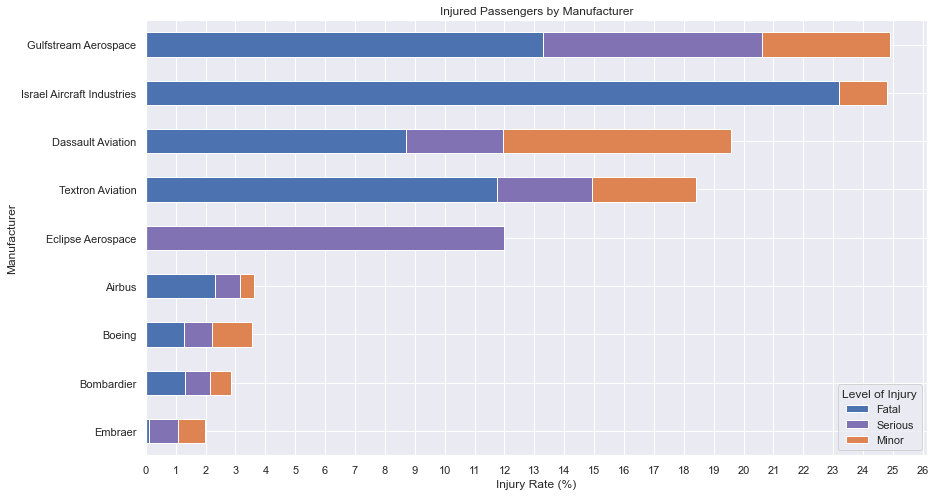

In [26]:
# prepare injury rate data for the plot
df_injuries_percents = df_injuries.sort_values(by='Injury Rate (%)', ascending=True)
df_injuries_percents = df_injuries_percents[['Fatal Injury Rate (%)', 'Serious Injury Rate (%)', 
                                             'Minor Injury Rate (%)']]
df_injuries_percents.columns = df_injuries_percents.columns.str.replace(' Injury Rate \(%\)','')

# plot injury rate data
injury_rate_plot = df_injuries_percents.plot.barh(stacked=True, figsize=(14, 8), color=[default_palette[0], 
                                                                                        default_palette[4], 
                                                                                        default_palette[1]])
injury_rate_plot.set_title('Injured Passengers by Manufacturer')
injury_rate_plot.set_xlabel('Injury Rate (%)')
injury_rate_plot.set_ylabel('Manufacturer')
injury_rate_plot.legend(title='Level of Injury')
injury_rate_plot.xaxis.set_major_locator(ticker.MultipleLocator(1));

***Embraer*** airplanes have the lowest injury rate (%) based on passengers that have been involved in an aviation accident/incident.

***Bombardier, Boeing and Airbus*** also have a low injury rate (< 4%).

Whenever there is an aviation accident/incident it is important to keep the total number of injured passengers to a minimum. The injury rate (%) is based on the total number of impacted passengers in these aviation events.

In [27]:
# preparing injury rate data for Tableau viz
df_injuries_data = df_injuries_percents.stack()
df_injuries_data = df_injuries_data.reset_index().rename(columns={'level_1': 'Injury Level', 0: 'Injury Rate (%)'})

In [28]:
# save injury rate data to csv file
df_injuries_data.to_csv('data/injury_rates_by_manufacturer.csv', index=False)

In [29]:
# save injury rate plot as png file
injury_rate_fig = injury_rate_plot.get_figure()
injury_rate_fig.savefig('viz/injury_rates_by_manufacturer.png', dpi=300, bbox_inches='tight')

<a id="accidents"></a>
### Accidents vs Incidents

I created a pivot table in order to see the split between accidents vs incidents for each manufacturer. 

In [30]:
# analyse number of accidents vs incidents
event_type_pivot = pd.pivot_table(accidents_df_final, values='Total Uninjured', index='Manufacturer', 
                                  columns='Investigation Type', aggfunc='size', fill_value=0)

# percentage of accidents vs incidents by manufacturer
event_type_percents = event_type_pivot.copy()
event_type_percents['Accident Rate (%)'] = (event_type_percents['Accident'] / 
                                            (event_type_percents['Accident'] + 
                                             event_type_percents['Incident'])) * 100
event_type_percents['Incident Rate (%)'] = (event_type_percents['Incident'] / 
                                            (event_type_percents['Accident'] + 
                                             event_type_percents['Incident'])) * 100
event_type_percents.drop(columns=['Accident', 'Incident'], inplace=True)

# sort values
event_type_percents_sorted = event_type_percents.sort_values(by=['Accident Rate (%)', 'Incident Rate (%)'], 
                                                             ascending=[True,True])
event_type_percents_sorted

Investigation Type,Accident Rate (%),Incident Rate (%)
Manufacturer,,
Airbus,45.192308,54.807692
Boeing,53.012048,46.987952
Bombardier,60.305344,39.694656
Eclipse Aerospace,66.666667,33.333333
Embraer,70.930233,29.069767
Gulfstream Aerospace,74.285714,25.714286
Israel Aircraft Industries,79.166667,20.833333
Dassault Aviation,80.000000,20.000000
Textron Aviation,80.487805,19.512195


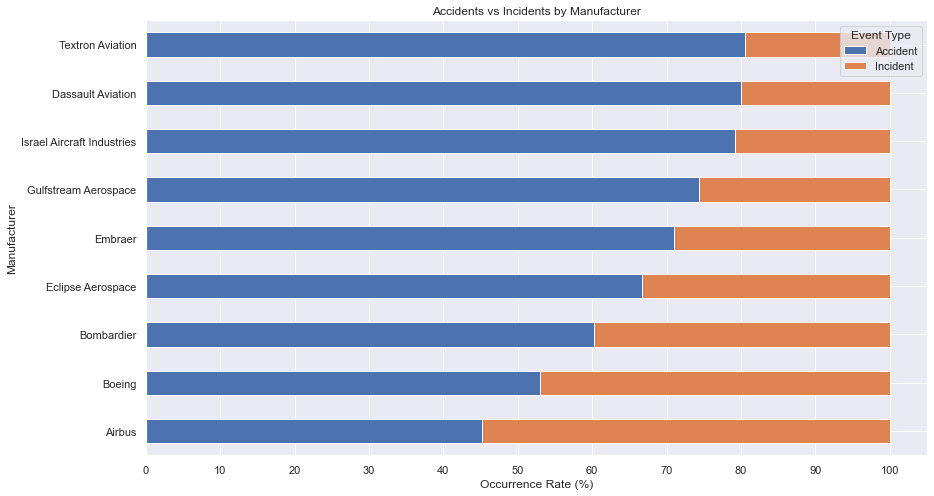

In [31]:
# prepare data for event type plot
event_type_percents_sorted.columns = event_type_percents_sorted.columns.str.replace(' Rate \(%\)','')

# plot accident vs incident percentages
event_type_plot = event_type_percents_sorted.plot.barh(stacked=True, figsize=(14, 8), 
                                                       color=[default_palette[0], default_palette[1]])
event_type_plot.set_title('Accidents vs Incidents by Manufacturer')
event_type_plot.set_xlabel('Occurrence Rate (%)')
event_type_plot.set_ylabel('Manufacturer')
event_type_plot.legend(title='Event Type')
event_type_plot.xaxis.set_major_locator(ticker.MultipleLocator(10));

***Airbus*** airplanes have the lowest accident rate (%) based on the comparison between accidents vs incidents by manufacturer. 

The accident rate is based on accidents data, it is not based on all flight data, it should not be used as a measure to determine the likelihood of an accident occurring. It represents the percentage of accidents by manufacturer when an incident has occurred.  

It is important to distinguish the difference between aviation accidents vs incidents, as accidents are more severe and have a higher chance of not only passengers sustaining injuries but also, the aircraft sustaining major damage. 

In [32]:
# preparing accident rate data for Tableau viz
df_event_type_data = event_type_percents_sorted.stack().reset_index()
df_event_type_data = df_event_type_data.rename(columns={0: 'Occurrence Rate (%)', 
                                                        'Investigation Type': 'Event Type'})

# save accident rate data to csv file
df_event_type_data.to_csv('data/accident_rates_by_manufacturer.csv', index=False)

In [33]:
# save accident rate plot as png file
event_type_fig = event_type_plot.get_figure()
event_type_fig.savefig('viz/accident_rates_by_manufacturer.png', dpi=300, bbox_inches='tight')

<a id="damage"></a>
### Level of Aircraft Damage

I created a pivot table in order to see the level of aircraft damage for each manufacturer.

In [34]:
# analyse aircraft damage numbers
aircraft_damage_pivot = pd.pivot_table(accidents_df_final, values='Total Uninjured', index='Manufacturer', 
                                       columns='Aircraft Damage', aggfunc='size', fill_value=0)

# analyse aircraft damage percentages
aircraft_damage_percents = aircraft_damage_pivot.copy()
aircraft_damage_percents['Total'] = (aircraft_damage_percents['Destroyed'] + 
                                     aircraft_damage_percents['Substantial'] + 
                                     aircraft_damage_percents['Minor'])
aircraft_damage_percents['Destroyed (%)'] = (aircraft_damage_percents['Destroyed'] / 
                                             aircraft_damage_percents['Total']) * 100
aircraft_damage_percents['Substantial (%)'] = (aircraft_damage_percents['Substantial'] / 
                                               aircraft_damage_percents['Total']) * 100
aircraft_damage_percents['Minor (%)'] = (aircraft_damage_percents['Minor'] / 
                                         aircraft_damage_percents['Total']) * 100
aircraft_damage_percents = aircraft_damage_percents[['Destroyed (%)', 'Substantial (%)', 'Minor (%)']]

# sort values
aircraft_damage_percents_sorted = aircraft_damage_percents.sort_values(by=['Destroyed (%)', 'Substantial (%)', 
                                                                           'Minor (%)'], 
                                                                       ascending=[True,True,True])
aircraft_damage_percents_sorted

Aircraft Damage,Destroyed (%),Substantial (%),Minor (%)
Manufacturer,,,
Eclipse Aerospace,0.000000,88.888889,11.111111
Embraer,1.162791,80.232558,18.604651
Boeing,3.253012,69.036145,27.710843
Airbus,4.807692,73.076923,22.115385
Bombardier,5.343511,70.229008,24.427481
Gulfstream Aerospace,11.428571,68.571429,20.000000
Textron Aviation,17.560976,71.707317,10.731707
Dassault Aviation,20.000000,60.000000,20.000000
Israel Aircraft Industries,29.166667,54.166667,16.666667


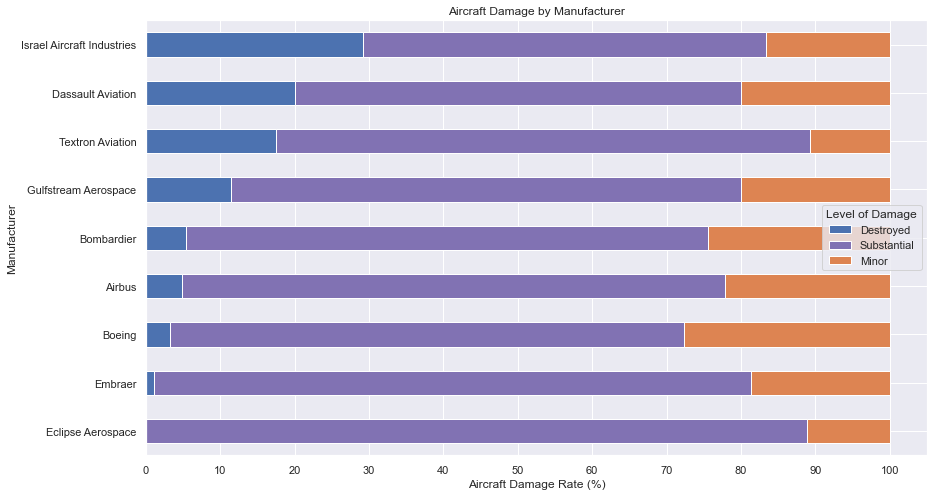

In [35]:
# prepare data for aircraft damage plot
aircraft_damage_percents_sorted.columns = aircraft_damage_percents_sorted.columns.str.replace(' \(%\)','')

# plot aircraft damage percentages
aircraft_damage_plot = aircraft_damage_percents_sorted.plot.barh(stacked=True, figsize=(14, 8), 
                                                                 color=[default_palette[0], default_palette[4], 
                                                                        default_palette[1]])
aircraft_damage_plot.set_title('Aircraft Damage by Manufacturer')
aircraft_damage_plot.set_xlabel('Aircraft Damage Rate (%)')
aircraft_damage_plot.set_ylabel('Manufacturer')
aircraft_damage_plot.legend(title='Level of Damage')
aircraft_damage_plot.xaxis.set_major_locator(ticker.MultipleLocator(10));

In the event of an aviation accident or incident, ***Boeing*** airplanes have the lowest aircraft damage rate (%), in regards to the aircraft sustaining major (destroyed or substantial) damage, compared with other manufacturers. 

This is an important consideration as the more damaged the aircraft, the higher chance of passengers getting injured and also, it maybe costly to replace or repair aircraft that suffer major damage after an accident or incident. 

In [36]:
# preparing aircraft damage rate data for Tableau viz
damage_rates_data = aircraft_damage_percents_sorted.stack()
damage_rates_data = damage_rates_data.reset_index().rename(columns={'Aircraft Damage': 'Aircraft Damage Level', 
                                                                    0: 'Aircraft Damage Rate (%)'})

# save aircraft damage rate data to csv file
damage_rates_data.to_csv('data/damage_rates_by_manufacturer.csv', index=False)

In [37]:
# save aircraft damage rate plot as png file
damage_rate_fig = aircraft_damage_plot.get_figure()
damage_rate_fig.savefig('viz/damage_rates_by_manufacturer.png', dpi=300, bbox_inches='tight')

<a id="conclusion"></a>
## Conclusion and Next Steps

Based on the analysis above, there are ***3 key recommendations*** as follows:

1. Having analysed the injury numbers against each manufacturer, my recommendation based on lowest injury rate (%) is ***Embraer*** airplanes, it is important in the event of an accident/incident that injured passengers are kept to a minimum.

2. Having analysed the number of accidents vs incidents per manufacturer, my recommendation based on lowest accident rate (%) is ***Airbus*** airplanes, the less severe the aviation event, means a lower chance of passengers and/or aircraft being injured/damaged. 

3. Having analysed the level of damage sustained by the airplanes for each manufacturer, my recommendation based on lowest aircraft damage rate (%) is ***Boeing*** airplanes. The level of aircraft damage is an important consideration, as major damage increases the chance of injured passengers and is likely more costly to replace or repair. 

**Next Steps**

- Contact ***Embraer***, ***Airbus*** and ***Boeing*** to find out about purchasing their business jets
    - Latest models
    - Pricing
    - Operational costs
    - Maintenance and support
    
- Create a shortlist of suitable business jets (Make/Model)

- Further deep dive / analysis of shortlisted airplanes
    - Obtaining all flight data for these airplanes, analysis to work out accident rate
    - Further analysis with the aviation accident data for these specific airplanes

<a id="references"></a>
## References

1. <a id="ref1"></a>https://www.bjtonline.com/business-jet-news/how-many-engines-do-you-need